In [ ]:
import numpy as np
import pandas as pd

def generate_data(seed):

    num_subjects = 1000
    num_features = 10

    rng = np.random.default_rng(seed)

    X_raw = rng.standard_normal(
        (num_subjects, num_features)
    )

    ones_column = np.ones(
        (num_subjects, 1)
    )

    X = np.concatenate(
        (ones_column, X_raw),
        axis=1
    )

    # 第一個是 intercept
    beta_true = np.array([
        1.0,   # intercept
        2.0,   # X1 effect
        -1.5,  # X2 effect
        0.5,   # X3 effect
        0.0,   # X4 no effect
        3.0,   # X5 effect
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]).reshape(-1, 1)


    noise = rng.standard_normal(
        (num_subjects, 1)
    )

    Y = (
        X @ beta_true
        + noise
        + X[:, 2:3] * X[:, 3:4] # X2 * X3 interaction
        + X[:, 4:5] * X[:, 4:5] # X4^2 quadratic term
    )

    columns = ["Intercept"] + [f"X{i}" for i in range(1, num_features+1)]

    data = pd.DataFrame(X, columns=columns)

    data["Y"] = Y.flatten()

    return data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


data = generate_data(seed=42)

X = data[[f"X{i}" for i in range(1, 11)]]
Y = data["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

Best alpha = 4.862601580065354
Best CV MSE = 4.490609873919598


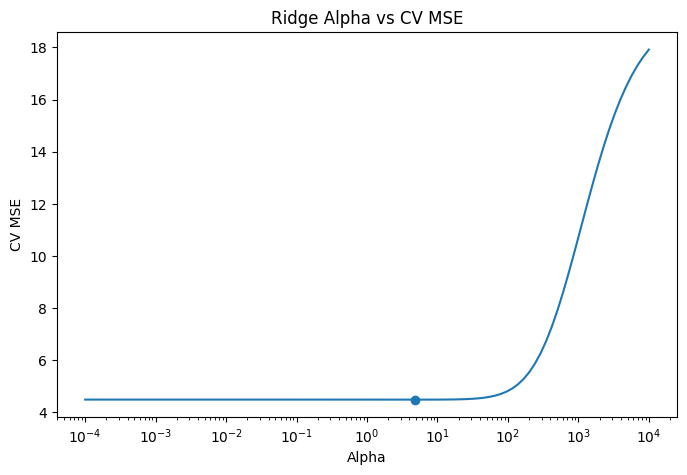

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline


alphas = np.logspace(-4, 4, 100)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mse_list = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    mse = -scores.mean()

    mse_list.append(mse)


# 找到 MSE 最小的 alpha
best_index = np.argmin(mse_list)
best_alpha = alphas[best_index]
best_mse = mse_list[best_index]

print("Best alpha =", best_alpha)
print("Best CV MSE =", best_mse)


# 畫圖
plt.figure(figsize=(8, 5))

plt.plot(alphas, mse_list)

plt.xscale("log")

plt.scatter(
    best_alpha,
    best_mse
)

plt.xlabel("Alpha")
plt.ylabel("CV MSE")
plt.title("Ridge Alpha vs CV MSE")

plt.show()

In [11]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 100)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(
        alphas=alphas,
        cv=5,
        scoring="neg_mean_squared_error"
    ))
])

model.fit(X_train, y_train)

best_alpha = model.named_steps["ridge"].alpha_

print("Best alpha =", best_alpha)

Best alpha = 4.037017258596558
